## Topological Defect Detection Demo

This notebook will demonstrate a basic method utilizing persistent homology to detect synthetic defects simulated in real data.

We will also show a comparable convolutional network on the same mesh to validate performance.

In [1]:
from Mesh import *
from mesh_deformations import *
from topology import *

### Example

Here is a quick example of the deformation process. Likely there are better ways to do this but it serves our purposes.

Below we use a set ray for demonstration purposes, but you can experiment with a random defect through
```
ray_origin, ray_direction = generate_random_ray(base_mesh, target_jitter=0.05)
```

In [3]:
file_path = "train/Screws and bolts with hexagonal head/00005000.obj"
base_mesh = Mesh(file_path)

print("--- Initial Mesh ---")
print(f"Vertices: {len(base_mesh.vertices)}, Faces: {len(base_mesh.faces)}")

ray_origin = [-0.7849299286403524, 2.099186573678783, 0.6925181038944663]
ray_direction = [0.44940335987347124, -0.8646277206920406, -0.22462307260235279]

# Create a ray-based dent mesh
dented_mesh = ray_dent_mesh(base_mesh, ray_origin, ray_direction, depth_fraction=0.4)
print("\n--- Ray Dent ---")
print(f"Dented Mesh Vertices: {len(dented_mesh.vertices)}, Faces: {len(dented_mesh.faces)}")

# Create a ray-based hole mesh
holed_mesh = ray_hole_mesh(base_mesh, ray_origin, ray_direction)
print("\n--- Ray Hole ---")
print(f"Holed Mesh Vertices: {len(holed_mesh.vertices)}, Faces: {len(holed_mesh.faces)}")

--- Initial Mesh ---
Vertices: 774, Faces: 1544

--- Ray Dent ---
Dented Mesh Vertices: 775, Faces: 1546

--- Ray Hole ---
Holed Mesh Vertices: 774, Faces: 1548


In [4]:
visualize_mesh(base_mesh)

Widget(value='<iframe src="http://localhost:37591/index.html?ui=P_0x7051237377f0_0&reconnect=auto" class="pyvi…

In [5]:
visualize_mesh(holed_mesh)

Widget(value='<iframe src="http://localhost:37591/index.html?ui=P_0x705113b02230_1&reconnect=auto" class="pyvi…

In [6]:
visualize_mesh(dented_mesh)

Widget(value='<iframe src="http://localhost:37591/index.html?ui=P_0x705110765c90_2&reconnect=auto" class="pyvi…

### Barcodes

Below are some plotting functions for the barcodes for the above meshes. Persistent homology is well-aligned for this problem, so it is likely defects are visible from casual observation even without a network.

Computing persistence barcode for direction: XY-0° [1.0, 0.0, 0.0]
Computing persistence barcode for direction: XY-60° [0.5000000000000001, 0.8660254037844386, 0.0]
Computing persistence barcode for direction: XY-120° [-0.4999999999999998, 0.8660254037844387, 0.0]
Computing persistence barcode for direction: XY-180° [-1.0, 1.2246467991473532e-16, 0.0]
Computing persistence barcode for direction: XY-240° [-0.5000000000000004, -0.8660254037844384, 0.0]
Computing persistence barcode for direction: XY-300° [0.49999999999999933, -0.866025403784439, 0.0]
Computing persistence barcode for direction: Above (+Z) [0.0, 0.0, 1.0]
Computing persistence barcode for direction: Below (-Z) [0.0, 0.0, -1.0]


/home/miguelomalley/pythonl/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:155: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


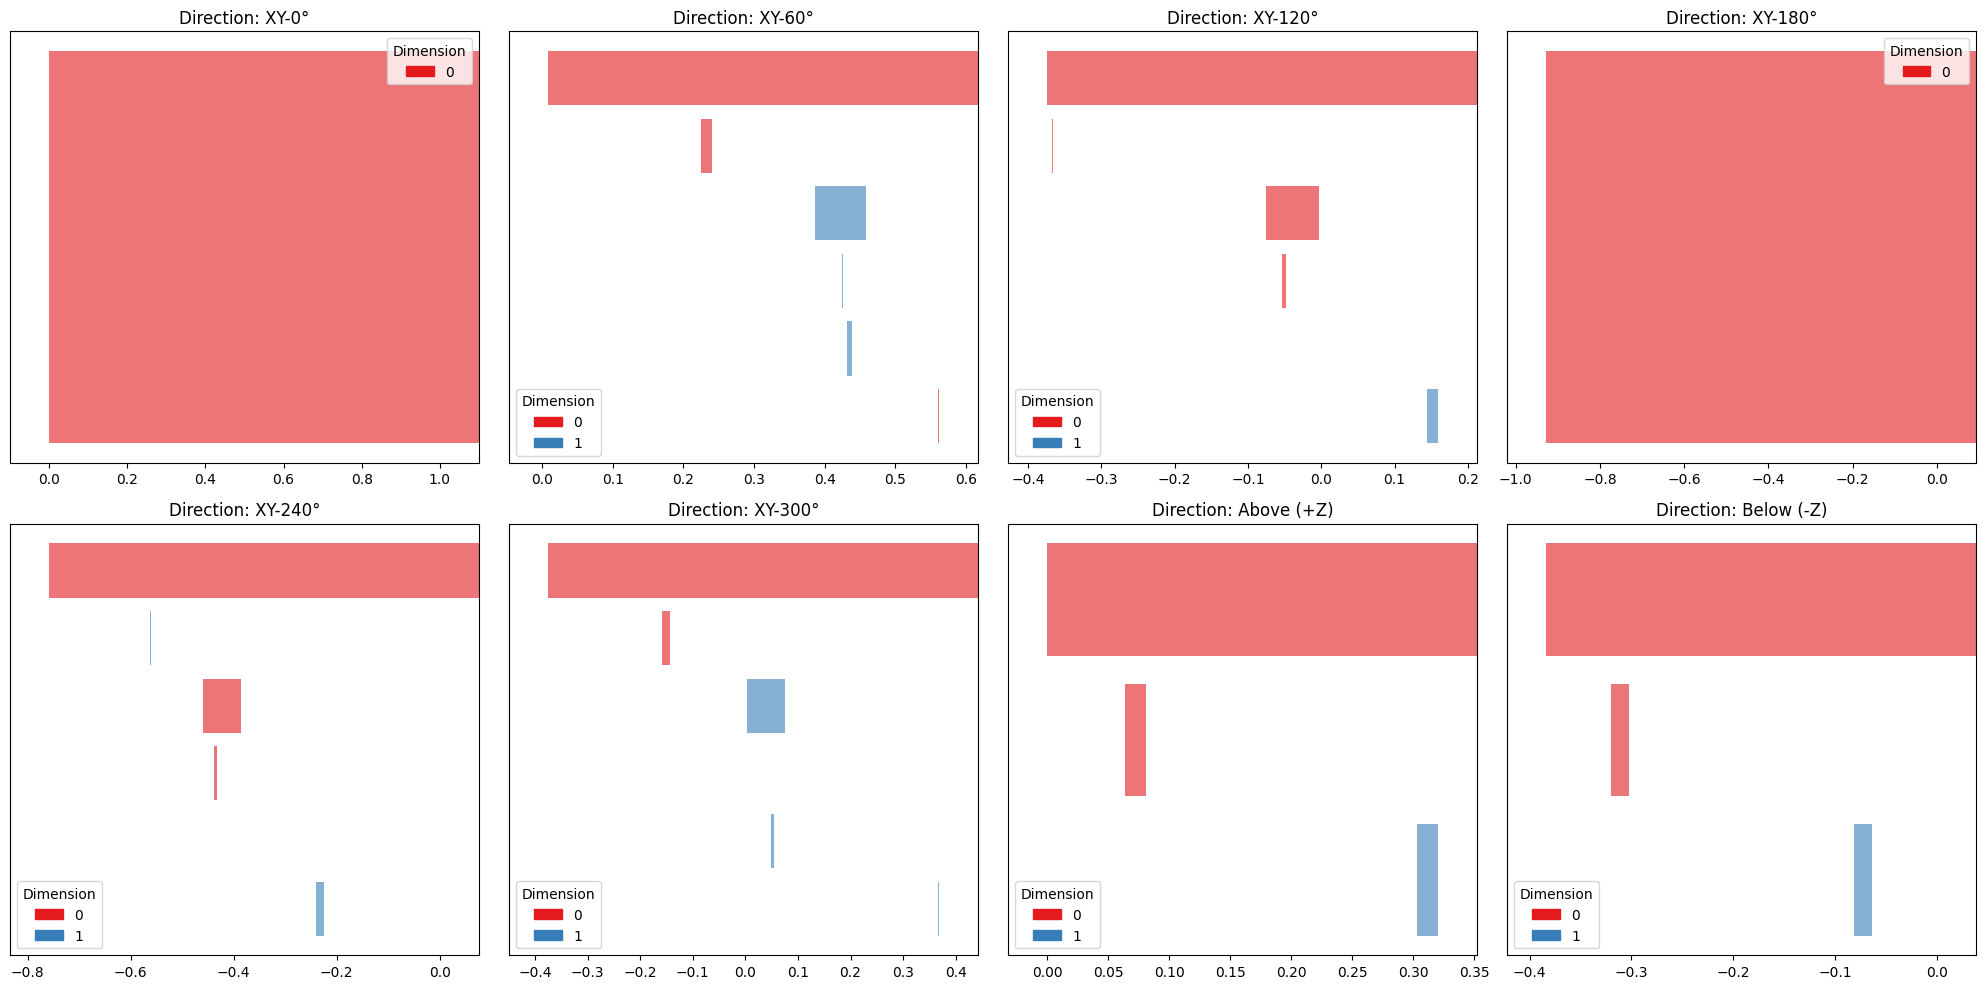

In [13]:
plot_mesh_barcodes(base_mesh)

Computing persistence barcode for direction: XY-0° [1.0, 0.0, 0.0]
Computing persistence barcode for direction: XY-60° [0.5000000000000001, 0.8660254037844386, 0.0]
Computing persistence barcode for direction: XY-120° [-0.4999999999999998, 0.8660254037844387, 0.0]
Computing persistence barcode for direction: XY-180° [-1.0, 1.2246467991473532e-16, 0.0]
Computing persistence barcode for direction: XY-240° [-0.5000000000000004, -0.8660254037844384, 0.0]
Computing persistence barcode for direction: XY-300° [0.49999999999999933, -0.866025403784439, 0.0]
Computing persistence barcode for direction: Above (+Z) [0.0, 0.0, 1.0]
Computing persistence barcode for direction: Below (-Z) [0.0, 0.0, -1.0]


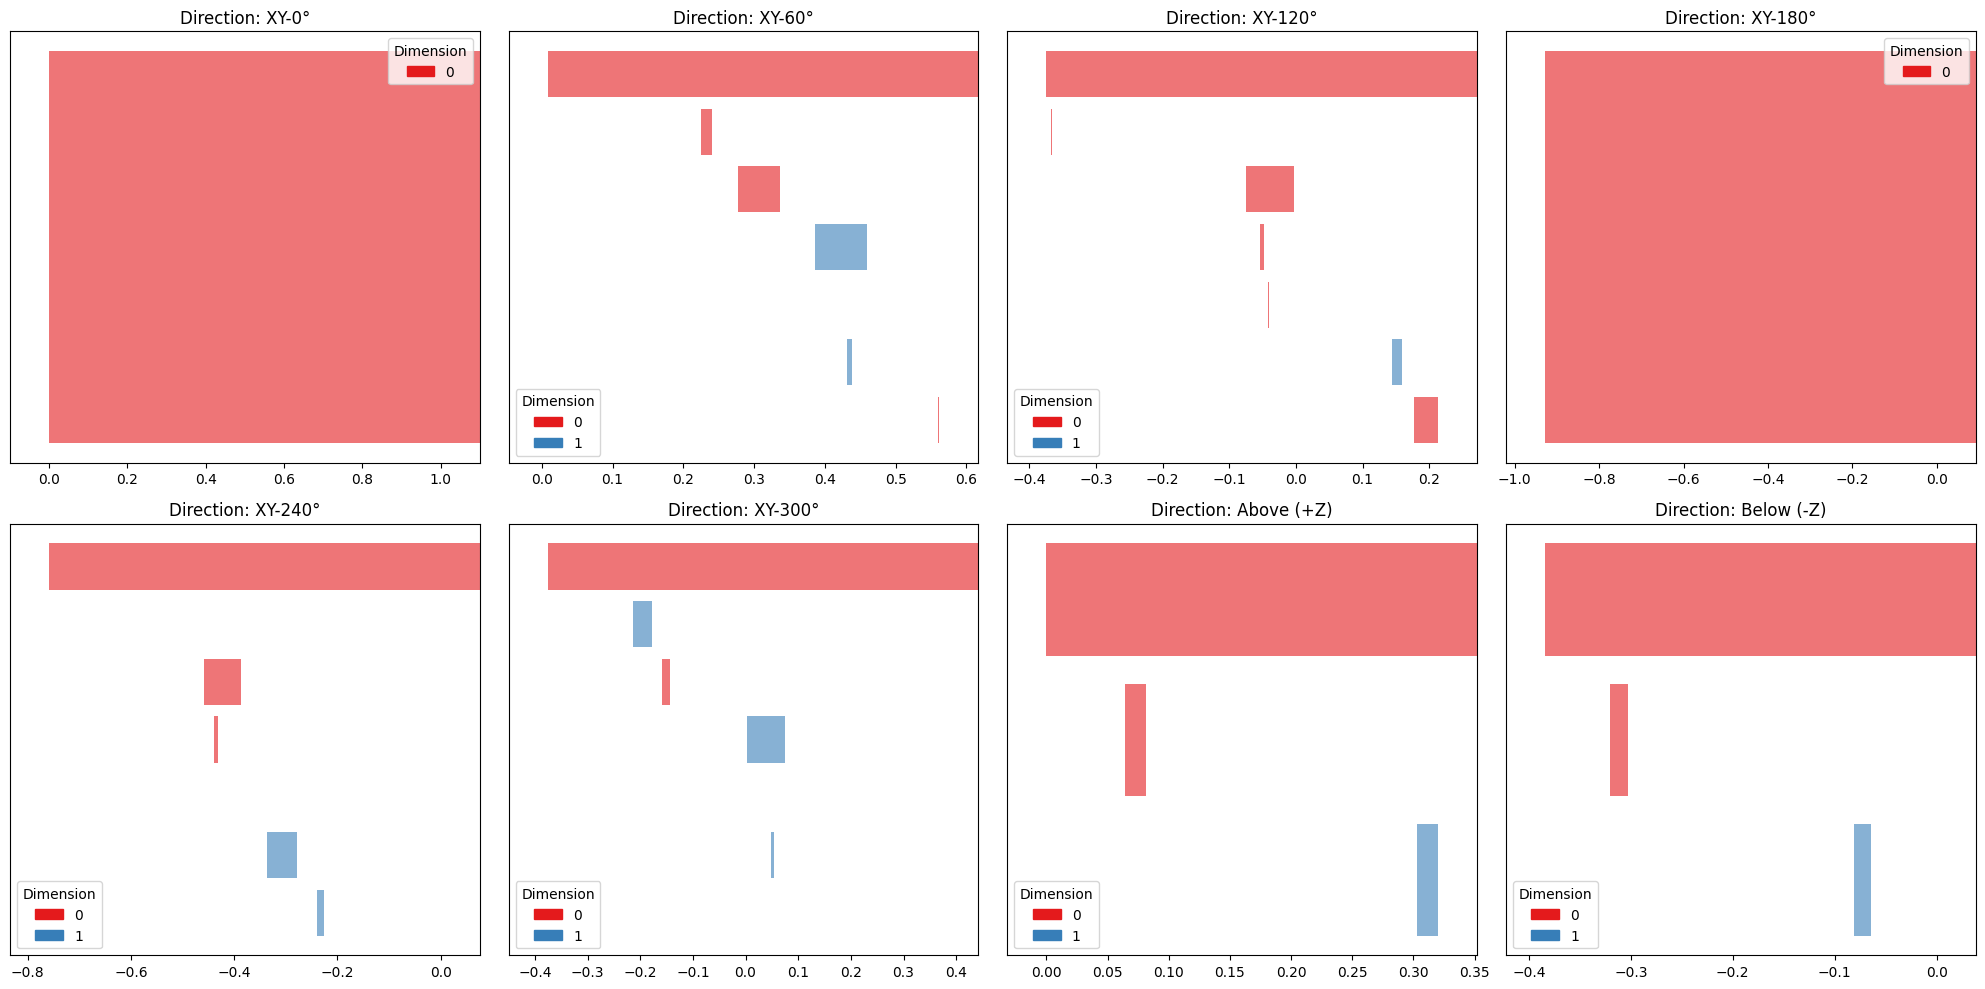

In [14]:
plot_mesh_barcodes(dented_mesh)

Computing persistence barcode for direction: XY-0° [1.0, 0.0, 0.0]
Computing persistence barcode for direction: XY-60° [0.5000000000000001, 0.8660254037844386, 0.0]
Computing persistence barcode for direction: XY-120° [-0.4999999999999998, 0.8660254037844387, 0.0]
Computing persistence barcode for direction: XY-180° [-1.0, 1.2246467991473532e-16, 0.0]
Computing persistence barcode for direction: XY-240° [-0.5000000000000004, -0.8660254037844384, 0.0]
Computing persistence barcode for direction: XY-300° [0.49999999999999933, -0.866025403784439, 0.0]
Computing persistence barcode for direction: Above (+Z) [0.0, 0.0, 1.0]
Computing persistence barcode for direction: Below (-Z) [0.0, 0.0, -1.0]


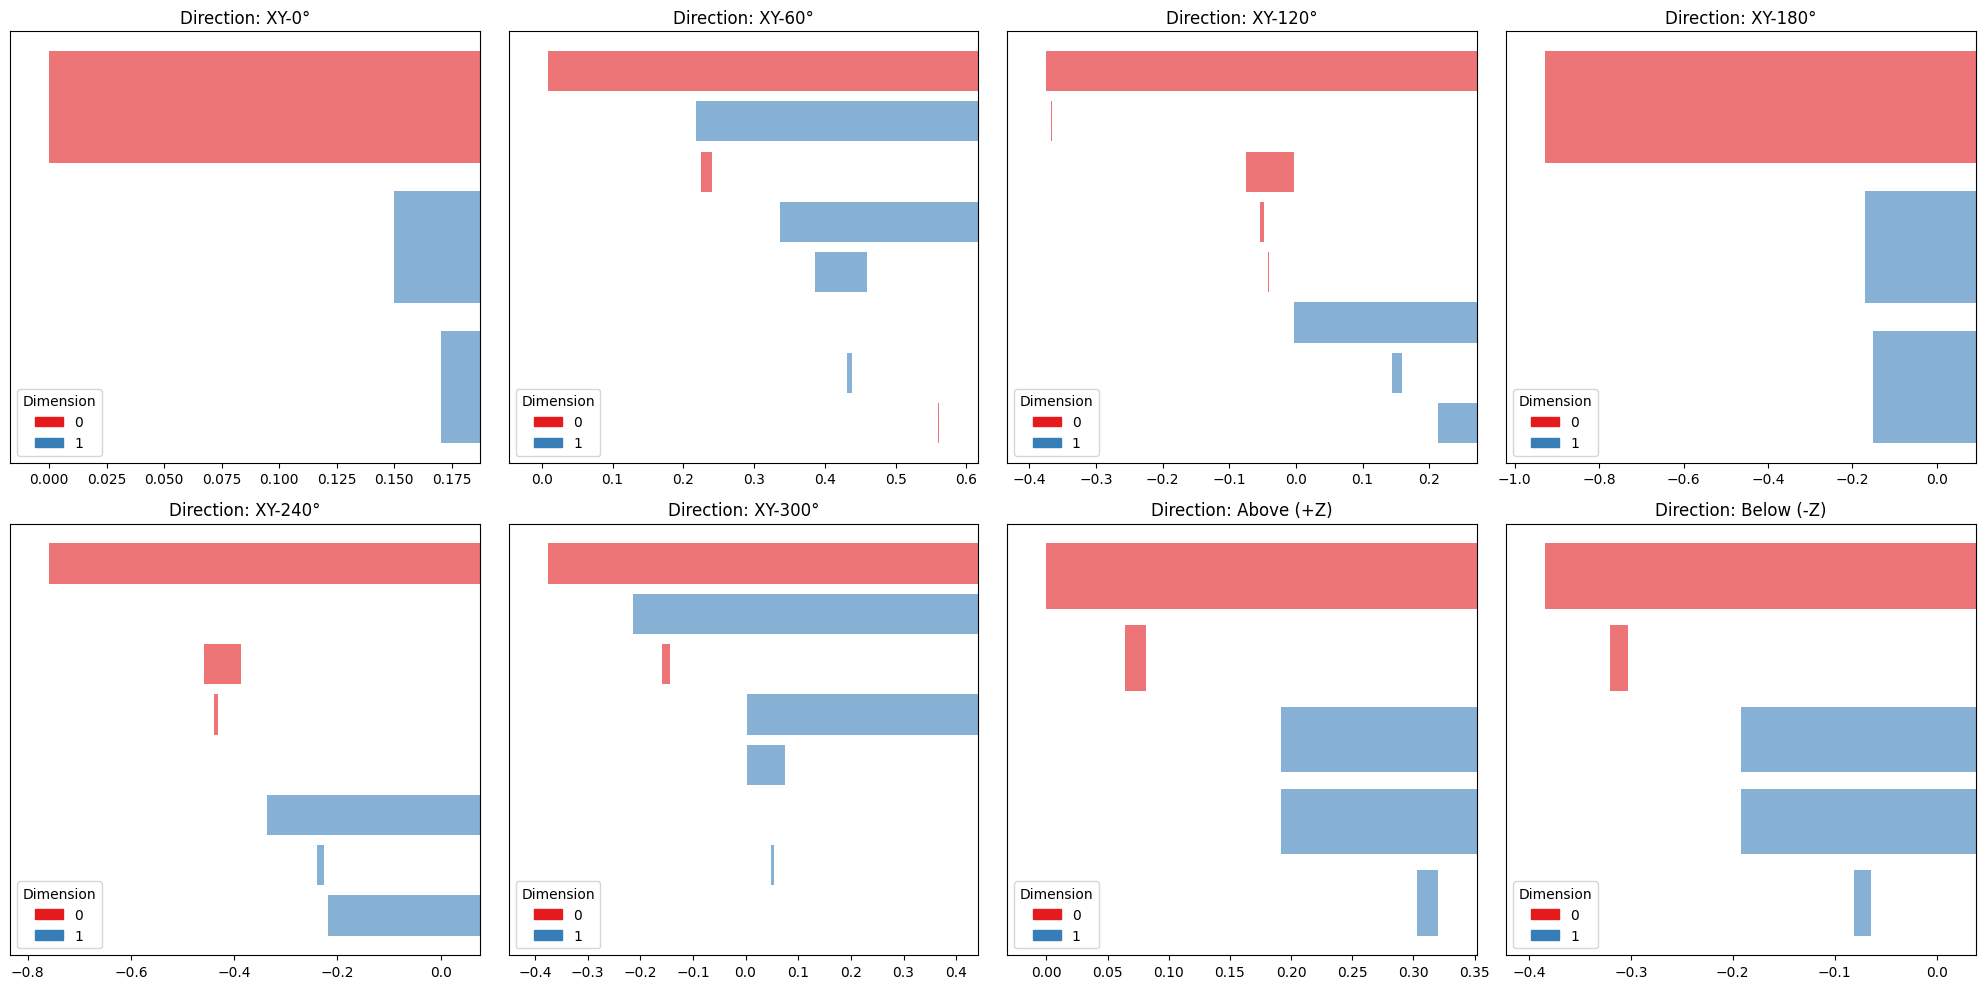

In [15]:
plot_mesh_barcodes(holed_mesh)

As you can see from the above barcodes, holes seem much more apparent than dents, which is to be expected. However, the dented screw still has clear distinguishing factors from the baseline, especially in the 60 and 300 degree directions.

## Training a Topological Classifier (PersNet)

To make use of the information we can glean through persistence, we will train a very simple network to parse barcodes for us. A more sophisticated network might produce better results, but since the barcode has already done a lot of the work for us, there is no pressing need.

The PersNet model is quite simple, we take as input a tensor of shape (B, 8, max_pers, 4) where max_pers denotes a maximal number of bars we're willing to process for any given direction of persistence. Each direction along the second dimension is flattened and processed through a stack of linear-ReLU layers. We concatenate the output from these layers and pass the result through more simple MLP classifier structure.

The output is a classification between three classes,
{0: Normal, 1: Hole, 2: Dent}

In [2]:
from config import Config
from models import PersNet
from train_notebook import train

Instead of the following, you may also simply call python train.py in the terminal

In [3]:
cfg = Config()
model = PersNet(cfg)
train(model)

Fetching barcodes...
--> Found cached topological features at 'cache/topo_cache_Screws_and_bolts_with_hexagonal_head.npz'. Loading directly from disk...
Split 'train' initialized in memory with 13551 total samples.
--> Found cached topological features at 'cache/topo_cache_Screws_and_bolts_with_hexagonal_head.npz'. Loading directly from disk...
Split 'test' initialized in memory with 1698 total samples.


Training Model:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch  1:   0%|          | 0/1694 [00:00<?, ?batch/s]

Epoch   1 | train loss 0.4683 acc 0.793 | test loss 0.3140 acc 0.869
 -> Saved new best model checkpoint! (Test Acc: 0.869)


Epoch  2:   0%|          | 0/1694 [00:00<?, ?batch/s]

...

Epoch  28 | train loss 0.0881 acc 0.973 | test loss 0.1743 acc 0.955


Epoch 29:   0%|          | 0/1694 [00:00<?, ?batch/s]

Epoch  29 | train loss 0.0863 acc 0.973 | test loss 0.1857 acc 0.953


Epoch 30:   0%|          | 0/1694 [00:00<?, ?batch/s]

Epoch  30 | train loss 0.0886 acc 0.973 | test loss 0.1565 acc 0.961
 -> Saved new best model checkpoint! (Test Acc: 0.961)

Done. PersNet best test accuracy achieved: 0.961


## Training a Conv3D classifier

With the same mesh, we can also train a simple Conv3D classifier to do the same job. Unlike PersNet, this requires relatively high dimensional information to be fed to the network up-front, so pre-processing will have some overhead.

Our Conv3D model is also fairly simple. We take a stack of 3 Conv3D layers at a stride of 2, to reduce dimension. The channels expand from 1->32->64->128. At the end of the stack, we condense to a single feature vector with adaptive max pooling to highlight important features detected during the conv stack. We process this final representation again through an MLP head before output.

In [4]:
from models import Conv3DNet
from train_conv_notebook import train as train_conv

As before, you may also run python train_conv.py in the terminal

In [5]:
cfg = Config()
conv_model = Conv3DNet(cfg)
train_conv(conv_model)